In [8]:
import torch as torch
import matplotlib.pyplot as plt

## RELU
Rectified linear unit

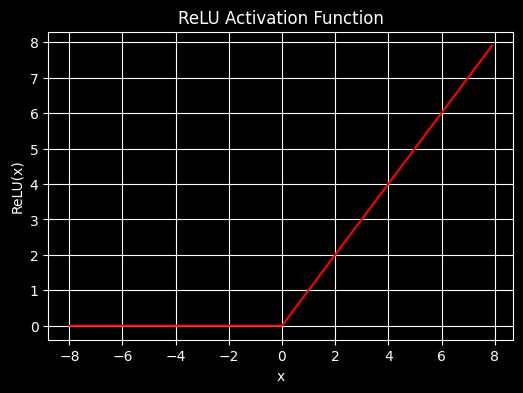

In [9]:

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)


plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), y.detach().numpy(),color='r')
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("ReLU Activation Function")
plt.grid(True)
plt.show()



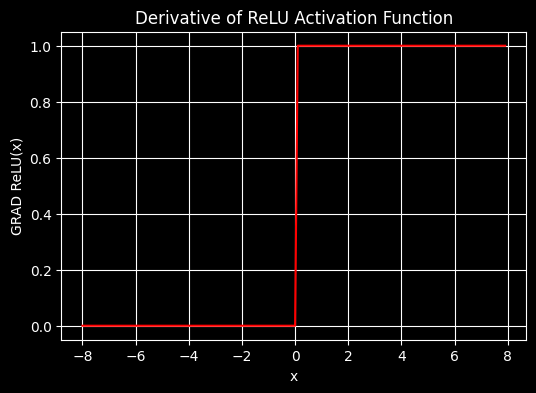

In [10]:
y.backward(torch.ones_like(x), retain_graph=True)
plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), x.grad.numpy(), color='r')
plt.xlabel("x")
plt.ylabel("GRAD ReLU(x)")
plt.title("Derivative of ReLU Activation Function")
plt.grid(True)
plt.show()


## Sigmoid

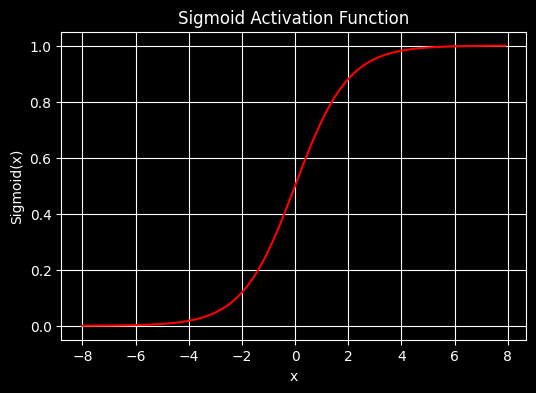

In [11]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)

plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), y.detach().numpy(),color='r')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Activation Function")
plt.grid(True)
plt.show()

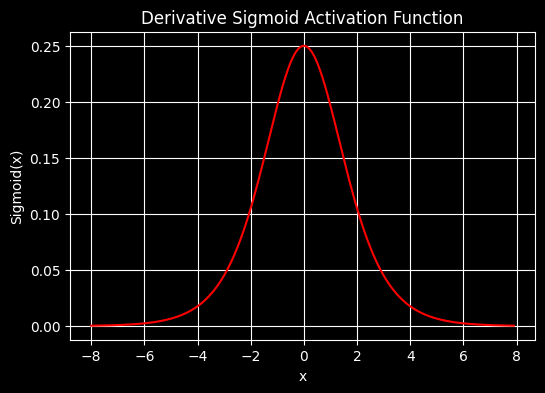

In [12]:
y.backward(torch.ones_like(x), retain_graph=True)


plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), x.grad.numpy(),color='r')
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Derivative Sigmoid Activation Function")
plt.grid(True)
plt.show()

## Tanh function

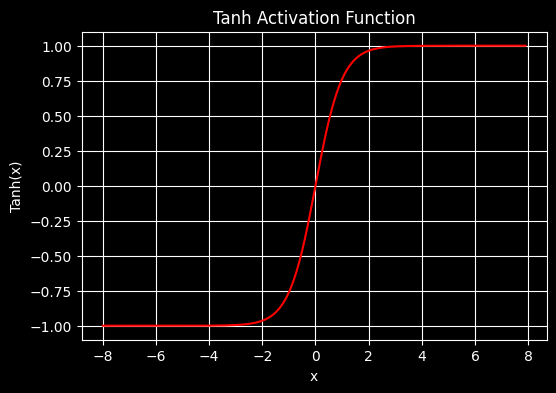

In [13]:
# Clear out previous gradients
x.grad.data.zero_()
y = torch.tanh(x)
plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), y.detach().numpy(),color='r')
plt.xlabel("x")
plt.ylabel("Tanh(x)")
plt.title("Tanh Activation Function")
plt.grid(True)
plt.show()


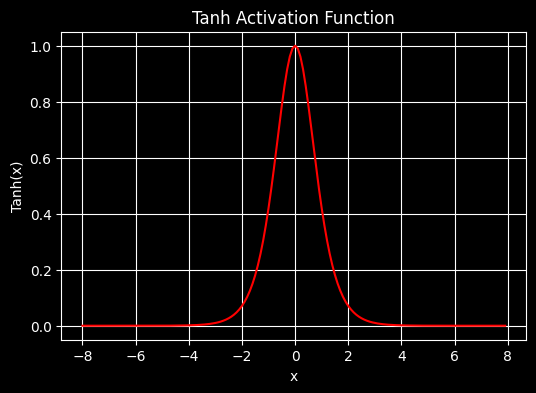

In [14]:
y.backward(torch.ones_like(x), retain_graph=True)
plt.figure(figsize=(6, 4))
plt.plot(x.detach().numpy(), x.grad.numpy(),color='r')
plt.xlabel("x")
plt.ylabel("Tanh(x)")
plt.title("Tanh Activation Function")
plt.grid(True)
plt.show()

# Implementation


Dataset: 900 samples, 2 features, 3 classes

Architecture: 2 → 64 → 32 → 3
  Layer 1: W(2, 64)  b(64,)
  Layer 2: W(64, 32)  b(32,)
  Layer 3: W(32, 3)  b(3,)

─── Training ───────────────────────────────────────
  Epoch   50/300  loss=0.3092  acc=94.1%  lr=0.03892
  Epoch  100/300  loss=0.1635  acc=96.7%  lr=0.03029
  Epoch  150/300  loss=0.1198  acc=98.4%  lr=0.02357
  Epoch  200/300  loss=0.1005  acc=98.6%  lr=0.01835
  Epoch  250/300  loss=0.0907  acc=99.0%  lr=0.01428
  Epoch  300/300  loss=0.0836  acc=99.0%  lr=0.01111

─── Classification of new samples ──────────────────
  Sample 1: x=[0.  0.9]  →  Class B (confidence 100.0%,  probs=[0. 1. 0.])
  Sample 2: x=[ 0.8 -0.3]  →  Class A (confidence 71.6%,  probs=[0.716 0.284 0.   ])
  Sample 3: x=[-0.6  0.1]  →  Class C (confidence 84.5%,  probs=[0.001 0.154 0.845])


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/mlp_results.png'

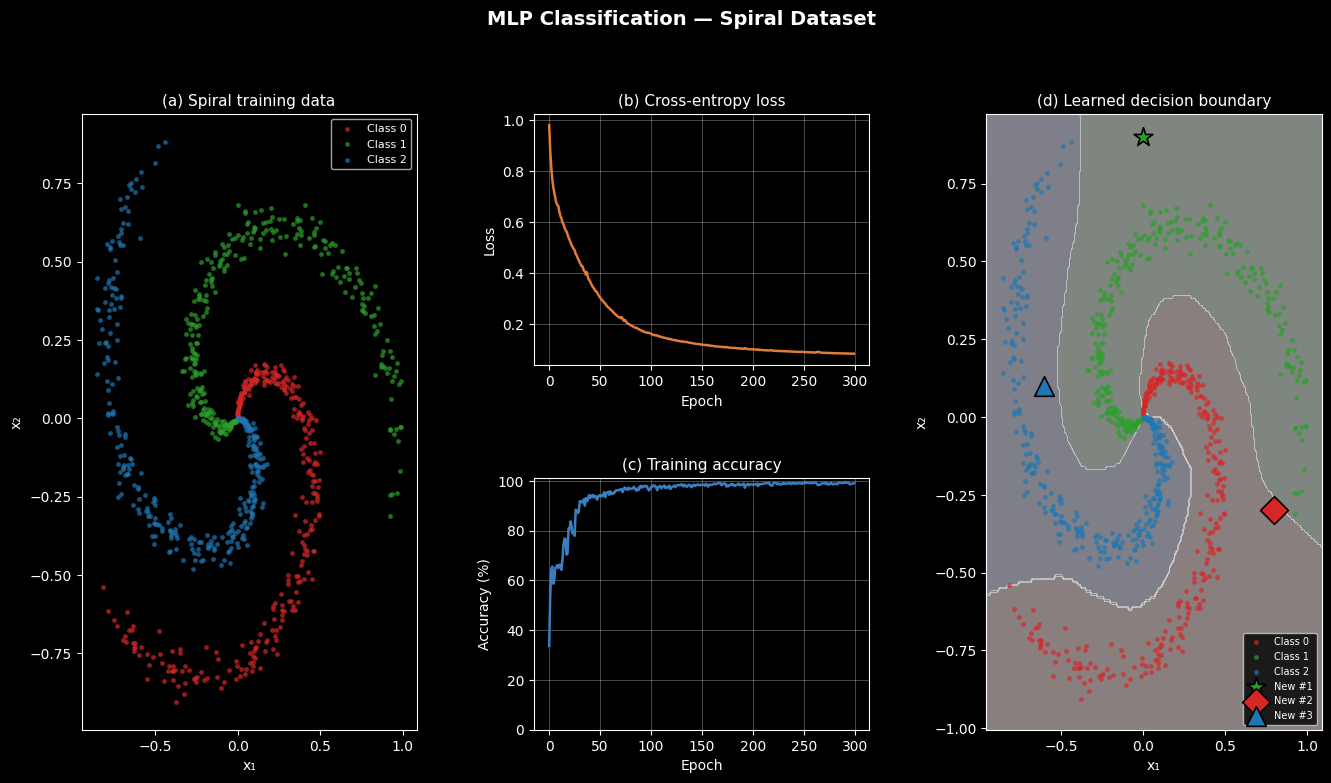

In [1]:
"""
Multilayer Perceptron (MLP) for Classification — from scratch with NumPy
=========================================================================
Covers:
  1. Training sample generation (spiral dataset)
  2. Network architecture definition
  3. Forward pass (linear → activation → softmax)
  4. Backward pass (cross-entropy gradient → chain rule → weight update)
  5. Training loop
  6. Classification of new samples with the trained network
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────
# 1. TRAINING SAMPLE GENERATION
#    Spiral dataset — 3 classes, 300 samples each
# ─────────────────────────────────────────────────────────────

def generate_spiral_data(n_samples_per_class: int = 300, n_classes: int = 3,
                         noise: float = 0.15, seed: int = 42) -> tuple:
    """
    Generates a spiral dataset with `n_classes` interleaved spirals.

    Returns:
        X : (N, 2)  float64 — 2-D feature vectors
        y : (N,)    int     — class labels 0 … n_classes-1
    """
    rng = np.random.default_rng(seed)
    N = n_samples_per_class * n_classes
    X = np.zeros((N, 2))
    y = np.zeros(N, dtype=int)

    for c in range(n_classes):
        ix = slice(c * n_samples_per_class, (c + 1) * n_samples_per_class)
        r = np.linspace(0.0, 1.0, n_samples_per_class)            # radius
        t = np.linspace(c * 4, (c + 1) * 4, n_samples_per_class)  # angle
        t += rng.standard_normal(n_samples_per_class) * noise
        X[ix] = np.column_stack([r * np.sin(t), r * np.cos(t)])
        y[ix] = c

    # Shuffle
    perm = rng.permutation(N)
    return X[perm], y[perm]


X, y = generate_spiral_data()
n_classes = len(np.unique(y))
n_features = X.shape[1]

print(f"Dataset: {X.shape[0]} samples, {n_features} features, {n_classes} classes")


# ─────────────────────────────────────────────────────────────
# 2. NETWORK ARCHITECTURE
#    Input(2) → Hidden1(64, ReLU) → Hidden2(32, ReLU) → Output(3, Softmax)
# ─────────────────────────────────────────────────────────────

def he_init(fan_in: int, fan_out: int, rng: np.random.Generator) -> np.ndarray:
    """He (Kaiming) initialisation — good default for ReLU activations."""
    std = np.sqrt(2.0 / fan_in)
    return rng.standard_normal((fan_in, fan_out)) * std


rng = np.random.default_rng(0)

architecture = [n_features, 64, 32, n_classes]   # layer sizes

# Weights and biases stored as lists (index i → layer i)
weights = []
biases  = []
for i in range(len(architecture) - 1):
    fan_in, fan_out = architecture[i], architecture[i + 1]
    weights.append(he_init(fan_in, fan_out, rng))
    biases.append(np.zeros(fan_out))

print(f"\nArchitecture: {' → '.join(str(s) for s in architecture)}")
for i, (W, b) in enumerate(zip(weights, biases)):
    print(f"  Layer {i+1}: W{W.shape}  b{b.shape}")


# ─────────────────────────────────────────────────────────────
# 3. ACTIVATION FUNCTIONS & HELPERS
# ─────────────────────────────────────────────────────────────

def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def relu_grad(z: np.ndarray) -> np.ndarray:
    """Element-wise derivative of ReLU (1 where z > 0, else 0)."""
    return (z > 0).astype(float)

def softmax(z: np.ndarray) -> np.ndarray:
    """Numerically stable softmax along axis=1 (row-wise)."""
    shifted = z - z.max(axis=1, keepdims=True)
    exp_z   = np.exp(shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def cross_entropy_loss(probs: np.ndarray, y: np.ndarray) -> float:
    """
    Mean cross-entropy loss.
    probs : (N, C) — softmax probabilities
    y     : (N,)   — integer class labels
    """
    N = len(y)
    log_p = -np.log(probs[np.arange(N), y] + 1e-12)
    return float(log_p.mean())

def accuracy(probs: np.ndarray, y: np.ndarray) -> float:
    return float((probs.argmax(axis=1) == y).mean())


# ─────────────────────────────────────────────────────────────
# 4. FORWARD PASS
# ─────────────────────────────────────────────────────────────

def forward(X: np.ndarray, weights: list, biases: list) -> tuple:
    """
    Full forward pass through the network.

    Returns:
        cache : dict holding pre-activations (z) and activations (a)
                for every layer — needed by backward pass.
        probs : (N, C) softmax output probabilities
    """
    cache = {"a0": X}

    a = X
    n_hidden = len(weights) - 1   # all layers except the final softmax layer

    # Hidden layers with ReLU
    for i in range(n_hidden):
        z = a @ weights[i] + biases[i]          # linear transform
        a = relu(z)                              # ReLU activation
        cache[f"z{i+1}"] = z
        cache[f"a{i+1}"] = a

    # Output layer — linear then softmax
    last = n_hidden
    z_out = a @ weights[last] + biases[last]
    probs = softmax(z_out)
    cache[f"z{last+1}"] = z_out
    cache[f"a{last+1}"] = probs                 # a_{last+1} == softmax probs

    return cache, probs


# ─────────────────────────────────────────────────────────────
# 5. BACKWARD PASS  (backpropagation)
# ─────────────────────────────────────────────────────────────

def backward(cache: dict, y: np.ndarray,
             weights: list, biases: list,
             l2_lambda: float = 1e-4) -> tuple:
    """
    Backpropagation through the network.

    Derivation outline
    ──────────────────
    Let L = number of weight layers.

    Output layer gradient (combined softmax + cross-entropy):
        δ_L = (probs - one_hot(y)) / N

    Hidden layer gradients (chain rule):
        δ_l = (δ_{l+1} @ W_{l+1}.T) * relu'(z_l)

    Parameter gradients:
        dW_l = a_{l-1}.T @ δ_l  +  λ * W_l   (L2 regularisation)
        db_l = sum(δ_l, axis=0)

    Returns:
        dW : list of weight gradients
        db : list of bias gradients
    """
    N   = len(y)
    L   = len(weights)              # number of weight layers
    dW  = [None] * L
    db  = [None] * L

    # ── Output layer δ (softmax cross-entropy combined gradient) ──────────
    probs = cache[f"a{L}"].copy()
    probs[np.arange(N), y] -= 1.0   # subtract 1 from the true-class slot
    delta = probs / N               # shape (N, C)

    # ── Iterate backwards from L down to 1 ───────────────────────────────
    for l in reversed(range(L)):
        a_prev = cache[f"a{l}"]                     # activation from layer below
        dW[l]  = a_prev.T @ delta + l2_lambda * weights[l]
        db[l]  = delta.sum(axis=0)

        if l > 0:
            # Propagate δ through the weight matrix, then through ReLU
            delta = delta @ weights[l].T * relu_grad(cache[f"z{l}"])

    return dW, db


# ─────────────────────────────────────────────────────────────
# 6. TRAINING LOOP  (mini-batch SGD)
# ─────────────────────────────────────────────────────────────

def train(X: np.ndarray, y: np.ndarray,
          weights: list, biases: list,
          n_epochs: int   = 300,
          batch_size: int = 128,
          lr: float       = 0.05,
          l2_lambda: float = 1e-4,
          decay: float    = 0.995) -> tuple:
    """
    Mini-batch SGD with learning-rate decay and L2 regularisation.

    Returns loss and accuracy history (one entry per epoch).
    """
    N = len(y)
    rng_loop = np.random.default_rng(7)
    loss_hist, acc_hist = [], []

    for epoch in range(n_epochs):
        # Shuffle training data each epoch
        perm = rng_loop.permutation(N)
        X_shuf, y_shuf = X[perm], y[perm]

        for start in range(0, N, batch_size):
            end    = min(start + batch_size, N)
            X_b    = X_shuf[start:end]
            y_b    = y_shuf[start:end]

            # Forward
            cache, probs = forward(X_b, weights, biases)

            # Backward
            dW, db = backward(cache, y_b, weights, biases, l2_lambda)

            # SGD update
            for i in range(len(weights)):
                weights[i] -= lr * dW[i]
                biases[i]  -= lr * db[i]

        # Epoch metrics on full training set
        _, probs_all = forward(X, weights, biases)
        loss = cross_entropy_loss(probs_all, y)
        acc  = accuracy(probs_all, y)
        loss_hist.append(loss)
        acc_hist.append(acc)

        # Learning-rate decay
        lr *= decay

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:4d}/{n_epochs}  "
                  f"loss={loss:.4f}  acc={acc*100:.1f}%  lr={lr:.5f}")

    return loss_hist, acc_hist


print("\n─── Training ───────────────────────────────────────")
loss_history, acc_history = train(X, y, weights, biases,
                                  n_epochs=300, batch_size=128,
                                  lr=0.05, l2_lambda=1e-4)


# ─────────────────────────────────────────────────────────────
# 7. CLASSIFICATION EXAMPLES  (new samples)
# ─────────────────────────────────────────────────────────────

print("\n─── Classification of new samples ──────────────────")

new_samples = np.array([
    [ 0.0,  0.9],   # near top of class-0 spiral
    [ 0.8, -0.3],   # class-1 region
    [-0.6,  0.1],   # class-2 region
])

_, new_probs = forward(new_samples, weights, biases)
predicted    = new_probs.argmax(axis=1)
class_names  = {0: "Class A", 1: "Class B", 2: "Class C"}

for i, (sample, pred, prob_row) in enumerate(zip(new_samples, predicted, new_probs)):
    conf = prob_row[pred] * 100
    print(f"  Sample {i+1}: x={sample}  →  {class_names[pred]} "
          f"(confidence {conf:.1f}%,  probs={prob_row.round(3)})")


# ─────────────────────────────────────────────────────────────
# 8. VISUALISATION
# ─────────────────────────────────────────────────────────────

def plot_decision_boundary(ax, weights, biases, X, y, title="Decision boundary"):
    """Plots the decision regions learned by the network."""
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, probs_grid = forward(grid, weights, biases)
    Z = probs_grid.argmax(axis=1).reshape(xx.shape)

    colors_bg  = ["#fde8e8", "#e8f4e8", "#e8e8fd"]
    colors_pts = ["#d62728", "#2ca02c", "#1f77b4"]
    from matplotlib.colors import ListedColormap
    cmap_bg = ListedColormap(colors_bg)

    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
    for c, col in enumerate(colors_pts):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=12, color=col,
                   label=f"Class {c}", alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
    ax.legend(fontsize=8, loc="upper right")


fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) Raw data ──────────────────────────────────────────────
ax_data = fig.add_subplot(gs[:, 0])
colors_pts = ["#d62728", "#2ca02c", "#1f77b4"]
for c, col in enumerate(colors_pts):
    mask = y == c
    ax_data.scatter(X[mask, 0], X[mask, 1], s=12, color=col,
                    label=f"Class {c}", alpha=0.7, linewidths=0)
ax_data.set_title("(a) Spiral training data", fontsize=11)
ax_data.set_xlabel("x₁"); ax_data.set_ylabel("x₂")
ax_data.legend(fontsize=8)

# ── (b) Training loss ─────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, 1])
ax_loss.plot(loss_history, color="#e07b39", lw=1.8)
ax_loss.set_title("(b) Cross-entropy loss", fontsize=11)
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.grid(True, lw=0.4, alpha=0.5)

# ── (c) Training accuracy ─────────────────────────────────────
ax_acc = fig.add_subplot(gs[1, 1])
ax_acc.plot([a * 100 for a in acc_history], color="#3a7ebf", lw=1.8)
ax_acc.set_title("(c) Training accuracy", fontsize=11)
ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
ax_acc.set_ylim(0, 101)
ax_acc.grid(True, lw=0.4, alpha=0.5)

# ── (d) Decision boundary ─────────────────────────────────────
ax_db = fig.add_subplot(gs[:, 2])
plot_decision_boundary(ax_db, weights, biases, X, y,
                       title="(d) Learned decision boundary")

# ── New sample markers ────────────────────────────────────────
markers = ["*", "D", "^"]
for i, (s, pred) in enumerate(zip(new_samples, predicted)):
    ax_db.scatter(s[0], s[1], s=200, marker=markers[i],
                  color=colors_pts[pred], edgecolors="black",
                  linewidths=1.2, zorder=10, label=f"New #{i+1}")
ax_db.legend(fontsize=7, loc="lower right")

fig.suptitle("MLP Classification — Spiral Dataset", fontsize=14, fontweight="bold", y=1.01)

out_path = "mlp_results.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"\nPlot saved → {out_path}")
